In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
# GPU 활성화 끄기
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [4]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는?3
화씨온도는  37.4


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [5]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [7]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [11]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
               input_shape=(1,) # 입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


-  회귀분석 오차함수 : 
    MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [12]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
               # 손실함수          옵티마저이저      평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [13]:
# 학습 전 예측
model.predict(np.array([[0],
                        [0.01]]))

1/1 [==============================] - 0s 140ms/step


array([[ 0.        ],
       [-0.00132514]], dtype=float32)

In [14]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [15]:
#모델 학습시키기
hist=model.fit(scaled_data_C,scaled_data_F,epochs=1000,verbose=2)

Epoch 1/1000
4/4 - 1s - loss: 1.9277 - mae: 1.2720 - 813ms/epoch - 203ms/step
Epoch 2/1000
4/4 - 0s - loss: 1.8955 - mae: 1.2601 - 9ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 1.8741 - mae: 1.2523 - 11ms/epoch - 3ms/step
Epoch 4/1000
4/4 - 0s - loss: 1.8556 - mae: 1.2453 - 13ms/epoch - 3ms/step
Epoch 5/1000
4/4 - 0s - loss: 1.8392 - mae: 1.2393 - 12ms/epoch - 3ms/step
Epoch 6/1000
4/4 - 0s - loss: 1.8224 - mae: 1.2331 - 10ms/epoch - 3ms/step
Epoch 7/1000
4/4 - 0s - loss: 1.8046 - mae: 1.2264 - 10ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 1.7880 - mae: 1.2201 - 9ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 1.7735 - mae: 1.2146 - 8ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 1.7589 - mae: 1.2091 - 14ms/epoch - 4ms/step
Epoch 11/1000
4/4 - 0s - loss: 1.7429 - mae: 1.2030 - 12ms/epoch - 3ms/step
Epoch 12/1000
4/4 - 0s - loss: 1.7269 - mae: 1.1970 - 10ms/epoch - 3ms/step
Epoch 13/1000
4/4 - 0s - loss: 1.7104 - mae: 1.1906 - 8ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s

Epoch 110/1000
4/4 - 0s - loss: 0.5820 - mae: 0.6378 - 9ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 0.5741 - mae: 0.6328 - 7ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 0.5670 - mae: 0.6283 - 8ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 0.5596 - mae: 0.6237 - 8ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 0.5507 - mae: 0.6181 - 8ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 0.5425 - mae: 0.6129 - 7ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 0.5345 - mae: 0.6078 - 10ms/epoch - 3ms/step
Epoch 117/1000
4/4 - 0s - loss: 0.5274 - mae: 0.6033 - 8ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 0.5199 - mae: 0.5984 - 9ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 0.5127 - mae: 0.5938 - 8ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 0.5054 - mae: 0.5892 - 6ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 0.4976 - mae: 0.5841 - 7ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 0.4906 - mae: 0.5796 - 9ms/epoch - 2ms/step
Epoch 123/1

Epoch 218/1000
4/4 - 0s - loss: 0.1040 - mae: 0.2781 - 8ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.1030 - mae: 0.2768 - 7ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.1017 - mae: 0.2752 - 8ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.1011 - mae: 0.2745 - 7ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.1000 - mae: 0.2732 - 7ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.0989 - mae: 0.2718 - 7ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.0981 - mae: 0.2707 - 8ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.0974 - mae: 0.2699 - 8ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.0965 - mae: 0.2687 - 8ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.0957 - mae: 0.2678 - 8ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.0950 - mae: 0.2669 - 7ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.0943 - mae: 0.2657 - 8ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.0935 - mae: 0.2647 - 7ms/epoch - 2ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.0464 - mae: 0.1861 - 6ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.0461 - mae: 0.1854 - 7ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.0457 - mae: 0.1845 - 9ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.0453 - mae: 0.1838 - 8ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.0450 - mae: 0.1830 - 7ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.0447 - mae: 0.1823 - 9ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.0444 - mae: 0.1817 - 9ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.0440 - mae: 0.1810 - 8ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.0436 - mae: 0.1803 - 7ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.0432 - mae: 0.1794 - 8ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.0428 - mae: 0.1787 - 7ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.0425 - mae: 0.1780 - 8ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.0421 - mae: 0.1771 - 7ms/epoch - 2ms/step
Epoch 339/10

Epoch 434/1000
4/4 - 0s - loss: 0.0133 - mae: 0.0995 - 7ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.0130 - mae: 0.0985 - 9ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.0128 - mae: 0.0976 - 7ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.0126 - mae: 0.0967 - 8ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.0124 - mae: 0.0959 - 7ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.0121 - mae: 0.0951 - 8ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.0119 - mae: 0.0942 - 7ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.0117 - mae: 0.0934 - 9ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.0115 - mae: 0.0924 - 9ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.0113 - mae: 0.0917 - 7ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.0111 - mae: 0.0910 - 8ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.0109 - mae: 0.0902 - 8ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.0108 - mae: 0.0895 - 8ms/epoch - 2ms/step
Epoch 447/10

Epoch 541/1000
4/4 - 0s - loss: 2.1452e-04 - mae: 0.0126 - 7ms/epoch - 2ms/step
Epoch 542/1000
4/4 - 0s - loss: 1.9278e-04 - mae: 0.0120 - 8ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 1.7885e-04 - mae: 0.0114 - 7ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 1.5793e-04 - mae: 0.0108 - 8ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 1.4046e-04 - mae: 0.0101 - 9ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 1.2055e-04 - mae: 0.0095 - 7ms/epoch - 2ms/step
Epoch 547/1000
4/4 - 0s - loss: 1.0598e-04 - mae: 0.0089 - 8ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 9.0621e-05 - mae: 0.0082 - 8ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 7.5981e-05 - mae: 0.0075 - 8ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 6.5464e-05 - mae: 0.0070 - 7ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 5.2538e-05 - mae: 0.0062 - 8ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 4.3873e-05 - mae: 0.0057 - 9ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 3.3094e-

4/4 - 0s - loss: 7.2180e-07 - mae: 8.2386e-04 - 8ms/epoch - 2ms/step
Epoch 641/1000
4/4 - 0s - loss: 1.3229e-07 - mae: 3.5246e-04 - 8ms/epoch - 2ms/step
Epoch 642/1000
4/4 - 0s - loss: 8.6630e-07 - mae: 9.0564e-04 - 7ms/epoch - 2ms/step
Epoch 643/1000
4/4 - 0s - loss: 9.2342e-07 - mae: 9.1858e-04 - 8ms/epoch - 2ms/step
Epoch 644/1000
4/4 - 0s - loss: 6.4180e-08 - mae: 2.4732e-04 - 8ms/epoch - 2ms/step
Epoch 645/1000
4/4 - 0s - loss: 4.6273e-07 - mae: 6.5532e-04 - 7ms/epoch - 2ms/step
Epoch 646/1000
4/4 - 0s - loss: 8.9673e-07 - mae: 9.3046e-04 - 8ms/epoch - 2ms/step
Epoch 647/1000
4/4 - 0s - loss: 4.8647e-07 - mae: 6.8247e-04 - 7ms/epoch - 2ms/step
Epoch 648/1000
4/4 - 0s - loss: 4.3746e-07 - mae: 6.4869e-04 - 6ms/epoch - 2ms/step
Epoch 649/1000
4/4 - 0s - loss: 6.9975e-07 - mae: 8.1945e-04 - 7ms/epoch - 2ms/step
Epoch 650/1000
4/4 - 0s - loss: 7.5263e-07 - mae: 8.4536e-04 - 8ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 3.9258e-07 - mae: 6.1065e-04 - 7ms/epoch - 2ms/step
Epoch 6

Epoch 739/1000
4/4 - 0s - loss: 1.2958e-06 - mae: 0.0011 - 7ms/epoch - 2ms/step
Epoch 740/1000
4/4 - 0s - loss: 2.1825e-07 - mae: 4.5071e-04 - 7ms/epoch - 2ms/step
Epoch 741/1000
4/4 - 0s - loss: 2.6197e-07 - mae: 4.9143e-04 - 9ms/epoch - 2ms/step
Epoch 742/1000
4/4 - 0s - loss: 5.5583e-07 - mae: 7.1172e-04 - 7ms/epoch - 2ms/step
Epoch 743/1000
4/4 - 0s - loss: 1.3558e-06 - mae: 0.0011 - 7ms/epoch - 2ms/step
Epoch 744/1000
4/4 - 0s - loss: 9.5022e-08 - mae: 2.9270e-04 - 6ms/epoch - 2ms/step
Epoch 745/1000
4/4 - 0s - loss: 1.1362e-07 - mae: 3.2181e-04 - 7ms/epoch - 2ms/step
Epoch 746/1000
4/4 - 0s - loss: 8.3377e-07 - mae: 8.6440e-04 - 8ms/epoch - 2ms/step
Epoch 747/1000
4/4 - 0s - loss: 1.1402e-06 - mae: 9.6705e-04 - 7ms/epoch - 2ms/step
Epoch 748/1000
4/4 - 0s - loss: 9.1637e-08 - mae: 2.8737e-04 - 8ms/epoch - 2ms/step
Epoch 749/1000
4/4 - 0s - loss: 1.0234e-07 - mae: 3.0489e-04 - 8ms/epoch - 2ms/step
Epoch 750/1000
4/4 - 0s - loss: 7.2712e-07 - mae: 7.9662e-04 - 6ms/epoch - 2ms/step


4/4 - 0s - loss: 4.3555e-07 - mae: 6.2731e-04 - 8ms/epoch - 2ms/step
Epoch 838/1000
4/4 - 0s - loss: 2.1070e-07 - mae: 4.4780e-04 - 7ms/epoch - 2ms/step
Epoch 839/1000
4/4 - 0s - loss: 6.9062e-07 - mae: 8.0582e-04 - 7ms/epoch - 2ms/step
Epoch 840/1000
4/4 - 0s - loss: 7.0670e-07 - mae: 8.1187e-04 - 7ms/epoch - 2ms/step
Epoch 841/1000
4/4 - 0s - loss: 8.9389e-07 - mae: 8.9608e-04 - 8ms/epoch - 2ms/step
Epoch 842/1000
4/4 - 0s - loss: 1.8847e-07 - mae: 4.2490e-04 - 8ms/epoch - 2ms/step
Epoch 843/1000
4/4 - 0s - loss: 7.2314e-07 - mae: 8.3185e-04 - 8ms/epoch - 2ms/step
Epoch 844/1000
4/4 - 0s - loss: 8.9499e-07 - mae: 9.0949e-04 - 6ms/epoch - 2ms/step
Epoch 845/1000
4/4 - 0s - loss: 2.4128e-07 - mae: 4.7573e-04 - 7ms/epoch - 2ms/step
Epoch 846/1000
4/4 - 0s - loss: 4.8135e-07 - mae: 6.6912e-04 - 8ms/epoch - 2ms/step
Epoch 847/1000
4/4 - 0s - loss: 6.8632e-07 - mae: 8.1108e-04 - 6ms/epoch - 2ms/step
Epoch 848/1000
4/4 - 0s - loss: 8.1308e-07 - mae: 8.8154e-04 - 8ms/epoch - 2ms/step
Epoch 8

4/4 - 0s - loss: 4.8243e-07 - mae: 6.8188e-04 - 9ms/epoch - 2ms/step
Epoch 936/1000
4/4 - 0s - loss: 5.4838e-07 - mae: 7.2520e-04 - 9ms/epoch - 2ms/step
Epoch 937/1000
4/4 - 0s - loss: 4.3055e-07 - mae: 6.4191e-04 - 9ms/epoch - 2ms/step
Epoch 938/1000
4/4 - 0s - loss: 7.5612e-07 - mae: 8.4962e-04 - 9ms/epoch - 2ms/step
Epoch 939/1000
4/4 - 0s - loss: 5.3320e-07 - mae: 7.1683e-04 - 6ms/epoch - 2ms/step
Epoch 940/1000
4/4 - 0s - loss: 4.6424e-07 - mae: 6.6933e-04 - 8ms/epoch - 2ms/step
Epoch 941/1000
4/4 - 0s - loss: 7.4749e-07 - mae: 8.4775e-04 - 8ms/epoch - 2ms/step
Epoch 942/1000
4/4 - 0s - loss: 5.1286e-07 - mae: 7.0012e-04 - 8ms/epoch - 2ms/step
Epoch 943/1000
4/4 - 0s - loss: 6.8292e-07 - mae: 8.0533e-04 - 8ms/epoch - 2ms/step
Epoch 944/1000
4/4 - 0s - loss: 1.7733e-07 - mae: 4.1191e-04 - 9ms/epoch - 2ms/step
Epoch 945/1000
4/4 - 0s - loss: 4.6426e-07 - mae: 6.4541e-04 - 8ms/epoch - 2ms/step
Epoch 946/1000
4/4 - 0s - loss: 1.3304e-06 - mae: 0.0011 - 8ms/epoch - 2ms/step
Epoch 947/1

In [17]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

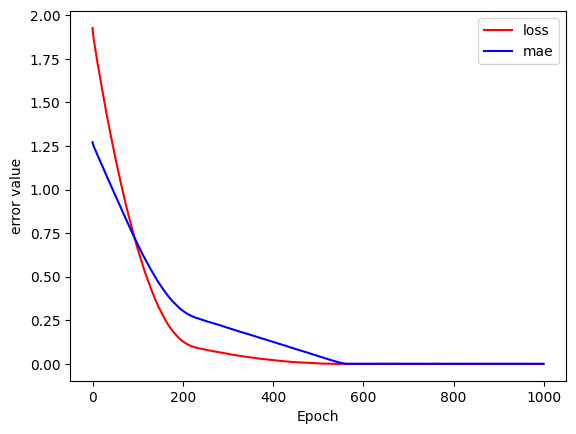

In [22]:
plt.plot(hist.history['loss'],'r',label='loss')
plt.plot(hist.history['mae'],'b',label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [24]:
#모델사용하기
model.predict(np.array([[0],
                       [0.01],
                       [0.02]]))

1/1 [==============================] - 0s 35ms/step


array([[0.31912684],
       [0.33712122],
       [0.3551156 ]], dtype=float32)

In [25]:
model.save('model/after_learning.h5')

In [10]:
#모델load
from tensorflow.keras.models import load_model
model=load_model('model/after_learning.h5')

In [12]:
model.predict(np.array([[0],
                       [0.01],
                       [0.02]])) #즉, 2차원버전

1/1 [==============================] - 0s 35ms/step


array([[0.31912684],
       [0.33712122],
       [0.3551156 ]], dtype=float32)

In [17]:
y_hat=model.predict([scaled_data_C])
square_error=0
for h,y in zip(y_hat,scaled_data_F):
     #print(h,y)
    square_error+=(h[0]-y)**2
square_error/100 #mse

4/4 [==============================] - 0s 2ms/step


1.3535300708789475e-06

<function matplotlib.pyplot.show(close=None, block=None)>

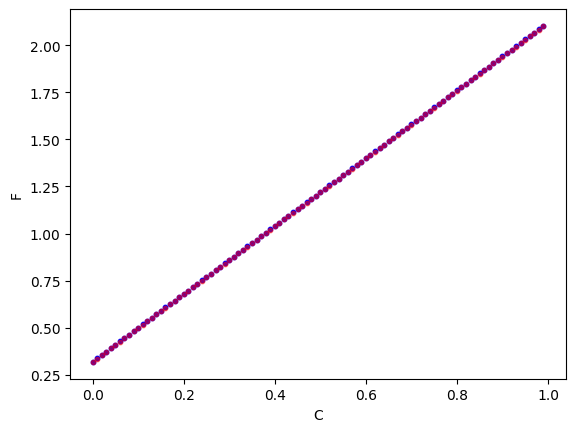

In [22]:
plt.scatter(x=scaled_data_C, y=scaled_data_F,c='b',s=10)
plt.scatter(x=scaled_data_C, y=y_hat,c='r',s=10,alpha=0.5)
plt.xlabel('C')
plt.ylabel('F')
plt.show

## 2.2 노이즈가 있는 데이터로 실습

In [24]:
#np.random.normal(100, scale=10, size=10) #평균0, 표준편차가 1일 넘파이 배열생성(size만큼)

array([111.35913729,  85.3971384 ,  94.79597882,  90.86418155,
        84.17066772, 100.10561019,  91.38752421, 103.13537857,
        77.89075167,  89.03485099])

In [27]:
np.random.seed(707)#강사랑 동일한 노이즈 희망시
noise=np.random.normal(0, scale=0.1, size=100) #평균0, 표준편차가 0.1일 넘파이 배열생성(size만큼)
noised_scaled_data_F=noise+scaled_data_F
noised_scaled_data_F

array([0.27500034, 0.20410134, 0.39498826, 0.27117424, 0.26897164,
       0.35314388, 0.4496784 , 0.42612159, 0.49409646, 0.45740286,
       0.31574183, 0.67996337, 0.46117139, 0.66152189, 0.45319086,
       0.4519712 , 0.73018132, 0.54170904, 0.68386841, 0.75022628,
       0.65735179, 0.76512782, 0.57019861, 0.79130977, 0.62965251,
       0.60058611, 0.81087191, 0.79345666, 0.90825121, 0.80020546,
       0.8489619 , 0.72808603, 0.98336163, 0.78173322, 0.8212351 ,
       1.05542797, 0.86566002, 0.99728791, 1.14628604, 0.93021808,
       0.91091956, 1.20887357, 0.89807223, 1.08124513, 0.95949964,
       1.24417872, 1.47029141, 0.89345844, 1.24009232, 1.26965718,
       1.39203371, 1.20086793, 1.17335862, 1.18484202, 1.26527807,
       1.25914114, 1.25582658, 1.46684352, 1.42267387, 1.38347091,
       1.34554506, 1.45325705, 1.58244673, 1.31622328, 1.38397926,
       1.53624202, 1.36919068, 1.51482044, 1.6480895 , 1.69886349,
       1.60323679, 1.68203012, 1.53758531, 1.57779451, 1.73967

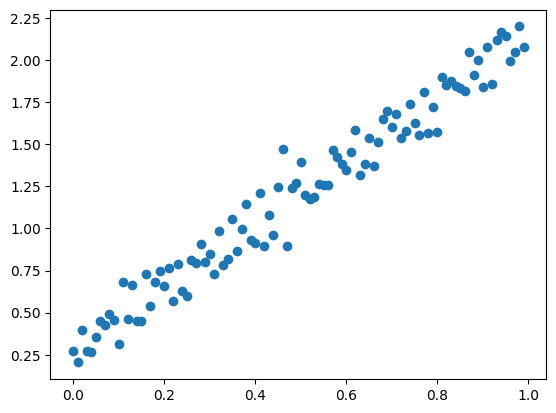

In [29]:
plt.scatter(x=scaled_data_C,y=noised_scaled_data_F)
plt.show()

In [44]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model2=Sequential()
model2.add(Dense(units=1,input_shape=(1,))) #units은 출력갯수, input_shape는 입력 shpe

# 4. 학습과정 설정..에러를줄이는 과정
model2.compile(loss='mse',optimizer='rmsprop',metrics=['mae'])
             # ==> '손실함수'     ==> '옵티마이저'   ==> '평가지표'
print(model2.summary)

<bound method Model.summary of <keras.engine.sequential.Sequential object at 0x000001AE42BE5A50>>


In [45]:
# 5. 학습시키기
hist2=model2.fit(scaled_data_C,
                 noised_scaled_data_F,
                 epochs=1000,
                 verbose=1)

Epoch 1/1000
4/4 [==============================] - 1s 5ms/step - loss: 4.9513 - mae: 1.9866
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.9018 - mae: 1.9752
Epoch 3/1000
4/4 [==============================] - 0s 4ms/step - loss: 4.8701 - mae: 1.9679
Epoch 4/1000
4/4 [==============================] - 0s 4ms/step - loss: 4.8380 - mae: 1.9605
Epoch 5/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.8089 - mae: 1.9537
Epoch 6/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.7804 - mae: 1.9469
Epoch 7/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.7565 - mae: 1.9414
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.7292 - mae: 1.9350
Epoch 9/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.7034 - mae: 1.9289
Epoch 10/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.6776 - mae: 1.9228
Epoch 11/1000
4/4 [==============================] - 0s 3ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 2.9768 - mae: 1.4751
Epoch 89/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.9573 - mae: 1.4696
Epoch 90/1000
4/4 [==============================] - 0s 4ms/step - loss: 2.9390 - mae: 1.4642
Epoch 91/1000
4/4 [==============================] - 0s 5ms/step - loss: 2.9205 - mae: 1.4588
Epoch 92/1000
4/4 [==============================] - 0s 4ms/step - loss: 2.9016 - mae: 1.4533
Epoch 93/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.8836 - mae: 1.4481
Epoch 94/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.8641 - mae: 1.4423
Epoch 95/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.8457 - mae: 1.4369
Epoch 96/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.8258 - mae: 1.4311
Epoch 97/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.8072 - mae: 1.4255
Epoch 98/1000
4/4 [==============================] - 0s 3ms/step - loss: 2

4/4 [==============================] - 0s 2ms/step - loss: 1.6023 - mae: 1.0414
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5906 - mae: 1.0373
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5772 - mae: 1.0325
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5640 - mae: 1.0277
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5522 - mae: 1.0234
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5409 - mae: 1.0195
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5271 - mae: 1.0147
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5153 - mae: 1.0104
Epoch 182/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5031 - mae: 1.0061
Epoch 183/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.4899 - mae: 1.0012
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.7504 - mae: 0.7119
Epoch 261/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.7443 - mae: 0.7094
Epoch 262/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.7374 - mae: 0.7066
Epoch 263/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.7308 - mae: 0.7037
Epoch 264/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.7233 - mae: 0.7007
Epoch 265/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.7185 - mae: 0.6986
Epoch 266/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.7126 - mae: 0.6962
Epoch 267/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.7047 - mae: 0.6929
Epoch 268/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6988 - mae: 0.6905
Epoch 269/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6923 - mae: 0.6877
Epoch 270/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.4014 - mae: 0.5498
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3991 - mae: 0.5484
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3980 - mae: 0.5476
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3966 - mae: 0.5467
Epoch 350/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.3953 - mae: 0.5457
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3931 - mae: 0.5443
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3914 - mae: 0.5430
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3890 - mae: 0.5412
Epoch 354/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.3875 - mae: 0.5403
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3859 - mae: 0.5390
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

...

4/4 [==============================] - 0s 2ms/step - loss: 0.1497 - mae: 0.3302
Epoch 605/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1489 - mae: 0.3293
Epoch 606/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1482 - mae: 0.3285
Epoch 607/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1474 - mae: 0.3277
Epoch 608/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1467 - mae: 0.3268
Epoch 609/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1458 - mae: 0.3260
Epoch 610/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1450 - mae: 0.3250
Epoch 611/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1444 - mae: 0.3243
Epoch 612/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1437 - mae: 0.3235
Epoch 613/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1431 - mae: 0.3226
Epoch 614/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0943 - mae: 0.2615
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0937 - mae: 0.2609
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0931 - mae: 0.2599
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0926 - mae: 0.2593
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0921 - mae: 0.2586
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0916 - mae: 0.2578
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0910 - mae: 0.2568
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0905 - mae: 0.2563
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0900 - mae: 0.2556
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0894 - mae: 0.2547
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0559 - mae: 0.1998
Epoch 777/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0555 - mae: 0.1991
Epoch 778/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0552 - mae: 0.1986
Epoch 779/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0549 - mae: 0.1979
Epoch 780/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0547 - mae: 0.1974
Epoch 781/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0542 - mae: 0.1967
Epoch 782/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0539 - mae: 0.1961
Epoch 783/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0535 - mae: 0.1954
Epoch 784/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0531 - mae: 0.1946
Epoch 785/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0528 - mae: 0.1941
Epoch 786/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0285 - mae: 0.1414
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0283 - mae: 0.1408
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0281 - mae: 0.1403
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0279 - mae: 0.1396
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0277 - mae: 0.1392
Epoch 867/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0275 - mae: 0.1387
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0273 - mae: 0.1381
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0271 - mae: 0.1376
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0269 - mae: 0.1370
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0267 - mae: 0.1366
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0155 - mae: 0.1040
Epoch 949/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0155 - mae: 0.1038
Epoch 950/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0154 - mae: 0.1035
Epoch 951/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0153 - mae: 0.1032
Epoch 952/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0152 - mae: 0.1030
Epoch 953/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0151 - mae: 0.1027
Epoch 954/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0151 - mae: 0.1027
Epoch 955/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0150 - mae: 0.1023
Epoch 956/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0150 - mae: 0.1022
Epoch 957/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0149 - mae: 0.1019
Epoch 958/1000
4/4 [==============================] - 0s 3ms/step

In [46]:
hist2.history.keys()

dict_keys(['loss', 'mae'])

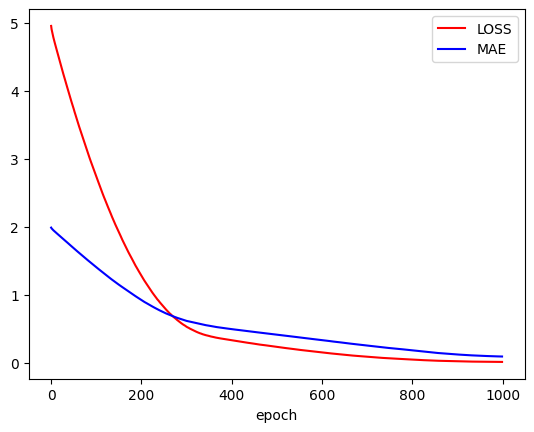

In [52]:
plt.plot(hist2.history['loss'],'r',label='LOSS')
plt.plot(hist2.history['mae'],'b',label='MAE')
plt.legend()
plt.xlabel('epoch')
plt.show()

In [57]:
y_hat=model2.predict([scaled_data_C])
square_error=0
for h,y in zip(y_hat,noised_scaled_data_F):
   # print(h,y)
    square_error+=(h[0]-y)**2
square_error/100 #mse

4/4 [==============================] - 0s 2ms/step


0.01215163787516504

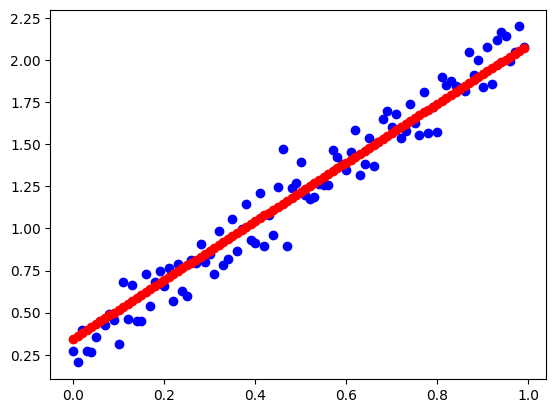

In [58]:
plt.scatter(x=scaled_data_C,y=noised_scaled_data_F,c='b')
plt.scatter(x=scaled_data_C,y=y_hat,c='r')
